## Data Preparation and Cleaning
The raw datasets are loaded and prepared for further spatial analysis. 


In [55]:
#import required libraries
import pandas as pd
import matplotlib.pyplot as plt
import functions 
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd

#load datasets
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")
raw_popsize = pd.read_csv("../data/raw/populationsize_zh.csv")
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")


#select needed columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]
processed_quartiere = raw_quartiere[["qname","geometry"]]
pop_size = raw_popsize[["QuarLang","AnzBestWir","StichtagDatJahr"]]


#define new column names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

new_names_2 = {
"QuarLang":"Quartier",
"AnzBestWir":"PopSize",
}
pop_size= pop_size.rename(columns=new_names_2)

# Check missing values

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_zwn dataset
#-------------------------------------------------------------------------------------------------------------------------

# convert datatype of "report_time" and "resolved_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create GeoDataFrame using the East and North coordinates as point geometry
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns (without East and North)
#processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]

#define CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

#-------------------------------------------------------------------------------------------------------------------------
# Prepare processed_quartiere dataset
#-------------------------------------------------------------------------------------------------------------------------

# Convert geometry column from string format into geometry objects
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

#define "Geometry" column as spatial geometry in a GeoDataFrame
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)


#-------------------------------------------------------------------------------------------------------------------------
# Prepare pop_size dataset
#-------------------------------------------------------------------------------------------------------------------------

# choose year 2025
pop_size= pop_size[raw_popsize["StichtagDatJahr"]	== 2025]
pop_size

,Quartier,PopSize,StichtagDatJahr
0,Rathaus,3252,2025
85,Hochschulen,688,2025
170,Lindenhof,1038,2025
255,City,769,2025
340,Wollishofen,22029,2025
425,Leimbach,6316,2025
510,Enge,10015,2025
595,Alt-Wiedikon,18904,2025
671,Friesenberg,11226,2025
747,Sihlfeld,21478,2025


In [35]:
#i
import matplotlib.pyplot as plt
import functions 
import pandas as pd
from shapely.geometry import Point
from shapely import wkt
import geopandas as gpd
raw_zwn = pd.read_csv("../data/raw/zwn_meldungen.csv")

#------------
# Clean data
#------------


#select useful columns
processed_zwn = raw_zwn[["service_name","requested_datetime","e","n","status","updated_datetime"]]

#define new columns names
new_names = {
"service_name":"category",
"e":"East",
"n":"North",
"requested_datetime":"report_time",
"updated_datetime":"resolved_time",
    }
processed_zwn= processed_zwn.rename(columns=new_names)

# convert datatype of "report_time" to datetime64
processed_zwn["report_time"] = pd.to_datetime(processed_zwn["report_time"], format ="%Y-%m-%dT%H:%M:%S")
processed_zwn["resolved_time"] = pd.to_datetime(processed_zwn["resolved_time"], format ="%Y-%m-%dT%H:%M:%S")

# create geometry category and geodataframe
import geopandas as gpd
from shapely.geometry import Point
processed_zwn = gpd.GeoDataFrame(processed_zwn,geometry=gpd.points_from_xy(processed_zwn["East"], processed_zwn["North"])
)
# select useful columns
processed_zwn= processed_zwn[["category","report_time","geometry","status","resolved_time"]]


# check missing values
#missing_count = processed_zwn[["category","report_time","geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#define missing CRS (CH1903+ / LV95)
processed_zwn = processed_zwn.set_crs(epsg=2056)

# load data quartiere
raw_quartiere = pd.read_csv("../data/raw/quartiere_zürich.csv")
processed_quartiere = raw_quartiere[["qname","geometry"]]
processed_quartiere.head(3)

#define new columns names
new_names1 = {
"qname":"Quartier",
    "geometry": "Geometry"
}
processed_quartiere= processed_quartiere.rename(columns=new_names1)

# check missing values
#missing_count = processed_quartiere[["Quartier","Geometry"]].isna().sum()
#print(f"The table shows the missing values in the dataframe {missing_count}")

#transform geometry datatype
#wkt.loads transform string datatype to geometry data type
from shapely import wkt
processed_quartiere["Geometry"] = processed_quartiere["Geometry"].apply(wkt.loads)

# create geodataframe to interprate "Geometry" as a geometry column
processed_quartiere = gpd.GeoDataFrame(
    processed_quartiere,
    geometry="Geometry")

#define missing CRS (CH1903+ / LV95)
processed_quartiere = processed_quartiere.set_crs(epsg=2056)

#download processed csv-files
#processed_zwn.to_file("../data/processed/processed_zwn.gpkg", driver="GPKG")
#processed_quartiere.to_file("../data/processed/processed_quartiere.gpkg", driver="GPKG")






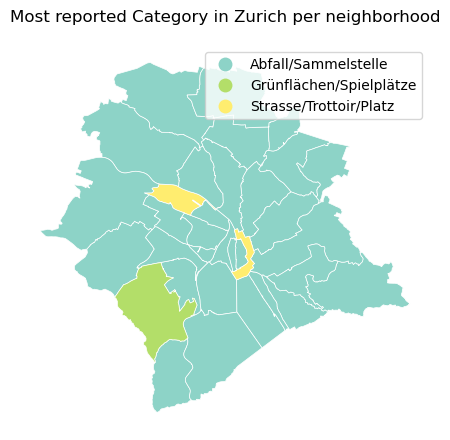

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


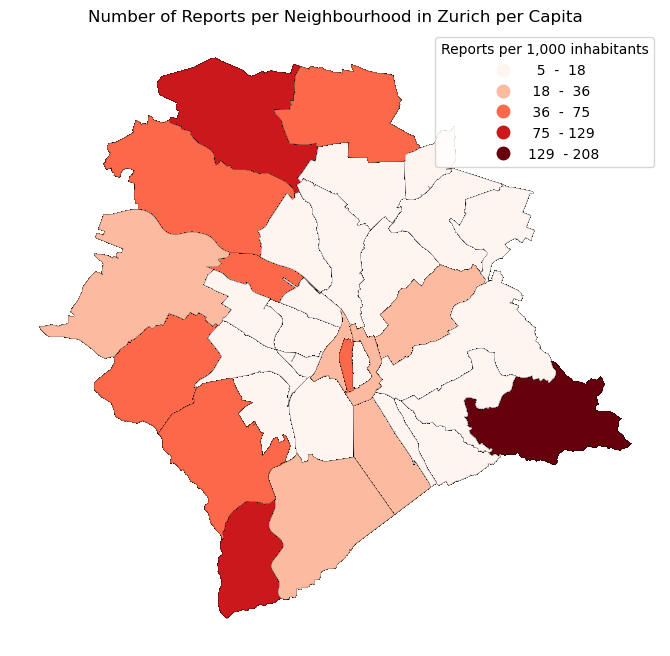

In [41]:
# Question 1: "What categories of problems are reported most frequently in each neighbo

#perform spatial join
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")




#count how many times a specific category in a specific quartier is reported
#reset_index wird verwendet, da Output sind Index(also Quartiernamen ist der Index) ist und man will wieder normale Spalten
#name="count" ist der Name der Spalte, sonst wäre er 0

count = zwn_with_quartiere.groupby(["Quartier","category"]).size().reset_index(name="count")
result = count.sort_values(["Quartier", "count"], ascending=[True, False]).drop_duplicates("Quartier")


#plot
import matplotlib.pyplot as plt
#verbindet beide Tabellen über Spalte Quartier
map_df = processed_quartiere.merge(result, on="Quartier",how="left") #left-->behalte alle Quartiere auch wenn kein Ergebnis existiert

fig, ax = plt.subplots(figsize=(10,5)) # creates empty figure "Graffiti": "red",

map_df.plot(
    column="category", #each Quartier gets a color based on its category
    categorical=True, # treat values as categories and not numbers
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax #draw the axes on the axes we creaed
)
ax.axis("off")
ax.set_title("Most reported Category in Zurich per neighborhood")

plt.show()
# Check NaN values in spatial join: 8 NaN values out of 72'411 reports
#zwn_with_quartiere["Quartier"].isna().sum()
#zwn_with_quartiere[zwn_with_quartiere["Quartier"].isna()]
#zwn_with_quartiere["Quartier"].notna().sum()

#ergänzend Frage1 Abfallmeldungen pro Einwohner pro Quartier, um herauszufinden wo das Abfallproblem das grösste Problem ist



merge1=processed_quartiere.merge(pop_size, on="Quartier",how="left")
filtered_Abfall = count[count["category"]=="Grünflächen/Spielplätze"]
merge2=merge1.merge(filtered_Abfall, on = "Quartier", how="left")

merge2["Abfallreports_per_capita"] = (merge2["count"]/merge2["PopSize"]*1000)




fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 
#plot

merge2.plot(
    column="Abfallreports_per_capita",
   scheme = "naturalbreaks",
   k = 5,
   edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Reds",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")

ax.axis("off")
plt.show()




## Question 1a: What categories of problems are most frequently reported in each neighbourhood?

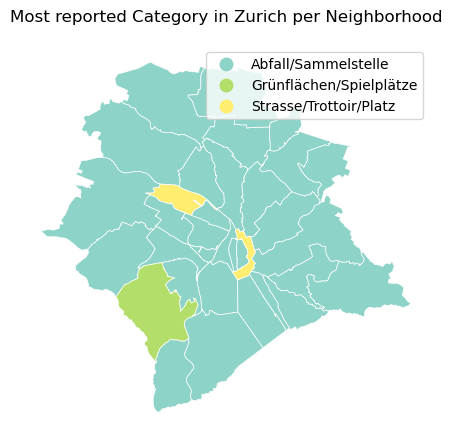

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=11.
  warnings.warn(


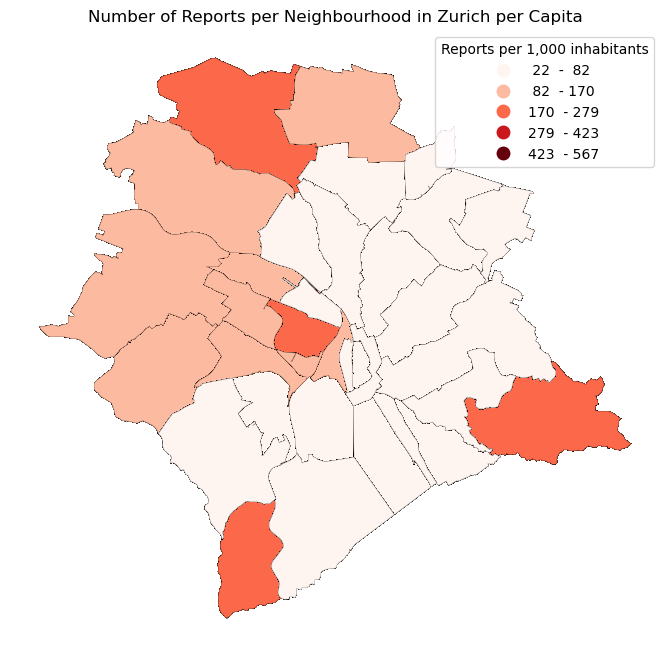

In [50]:
#----------------------------------------------------------------------------------------------------
#Spatial join: assign each report to a neighbourhood
#----------------------------------------------------------------------------------------------------
zwn_with_quartiere = gpd.sjoin(processed_zwn,processed_quartiere, how="left", predicate ="within")

#---------------------------------------------------------------------------------------------------
#Data Analysis: choose category with the most reported issues per neighbourhood
#---------------------------------------------------------------------------------------------------
count = zwn_with_quartiere.groupby(["Quartier","category"]).size().reset_index(name="count")
result = count.sort_values(["Quartier", "count"], ascending=[True, False]).drop_duplicates("Quartier")
map_df = processed_quartiere.merge(result, on="Quartier",how="left")

#---------------------------------------------------------------------------------------------------------
# Create Map
#---------------------------------------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(10,5)) # creates empty figure 

map_df.plot(
    column="category", 
    categorical=True,
    edgecolor = "white",
    legend=True,
    linewidth = 0.5,
    cmap = "Set3",
    ax=ax )

ax.axis("off")
ax.set_title("Most reported Category in Zurich per Neighborhood")

plt.show()

# Check NaN values in spatial join: 8 NaN values out of 72'411 reports
#zwn_with_quartiere["Quartier"].isna().sum()
#zwn_with_quartiere[zwn_with_quartiere["Quartier"].isna()]
#zwn_with_quartiere["Quartier"].notna().sum()

#ergänzend Frage1 Abfallmeldungen pro Einwohner pro Quartier, um herauszufinden wo das Abfallproblem das grösste Problem ist



merge1=processed_quartiere.merge(pop_size, on="Quartier",how="left")
filtered_Abfall = count[count["category"]=="Abfall/Sammelstelle"]
merge2=merge1.merge(filtered_Abfall, on = "Quartier", how="left")

merge2["Abfallreports_per_capita"] = (merge2["count"]/merge2["PopSize"]*1000)




fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 
#plot

merge2.plot(
    column="Abfallreports_per_capita",
   scheme = "naturalbreaks",
   k = 5,
   edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Reds",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")

ax.axis("off")
plt.show()




## Question 1b: Is a certain type of issue concentrated in particular neighbourhoods?

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


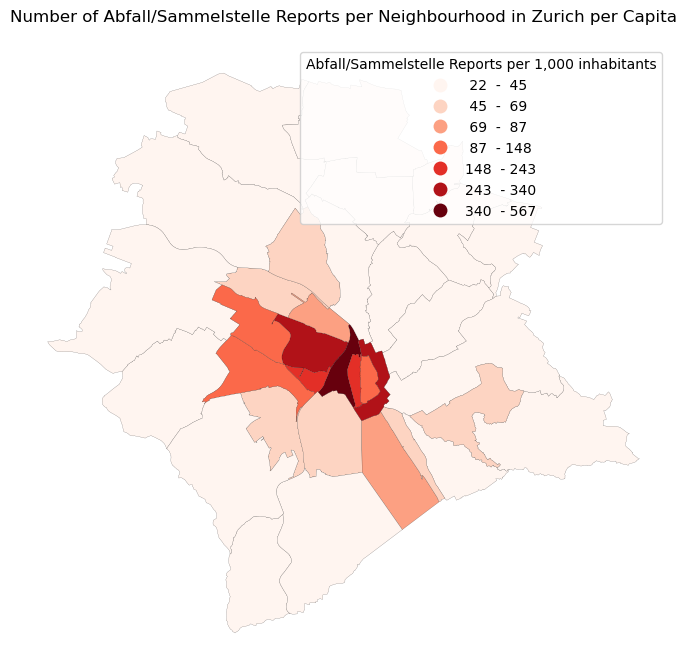

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


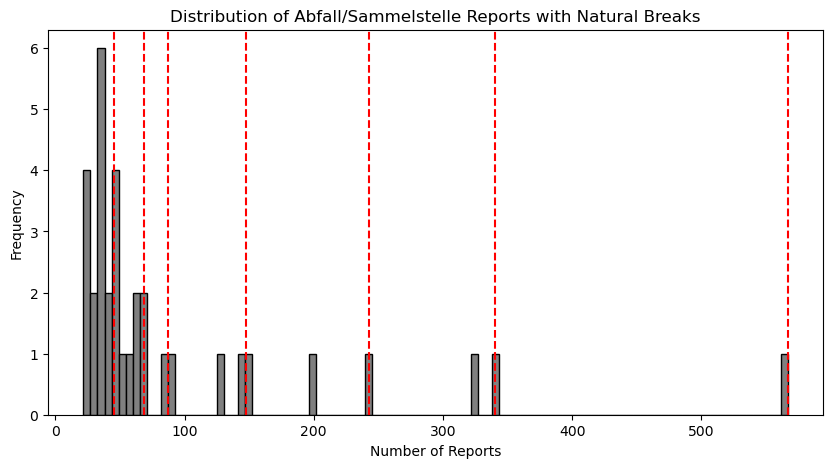

In [69]:
# ------------------------------------------------------------
# Prepare population and category data
# ------------------------------------------------------------
quartier_popsize=processed_quartiere.merge(pop_size, on="Quartier",how="left")

# Filter for selected issue category (changeable)
filtered_category = count[count["category"]=="Abfall/Sammelstelle"]

category_quartier_popsize=quartier_popsize.merge(filtered_category, on = "Quartier", how="left")

#---------------------------------------------------------------------------------------------------
#Data Analysis: Calculate number of reports per 1,000 inhabitants per neighbourhood
#---------------------------------------------------------------------------------------------------
category_quartier_popsize["Abfallreports_per_capita"] = (category_quartier_popsize["count"]/category_quartier_popsize["PopSize"]*1000)


#---------------------------------------------------------------------------------------------------------
# Create Chloropleth Map
#---------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


category_quartier_popsize.plot(
    column="Abfallreports_per_capita",
   scheme = "naturalbreaks",
   k = 7,
   edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Reds",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Abfall/Sammelstelle Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Abfall/Sammelstelle Reports per Neighbourhood in Zurich per Capita")

ax.axis("off")
plt.show()

#--------------------------------------------------------------------------------------------------------
# Create histogram
#--------------------------------------------------------------------------------------------------------

# create natural break classifier and extract class breaks
classifier = mapclassify.NaturalBreaks(category_quartier_popsize["Abfallreports_per_capita"],k=7)
breaks = classifier.bins


plt.figure(figsize=(10,5))
plt.hist(category_quartier_popsize["Abfallreports_per_capita"], bins=100, color= "grey",edgecolor="black")

# Draw red lines at the Natural Break position
for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Abfall/Sammelstelle Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")

plt.show()








C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


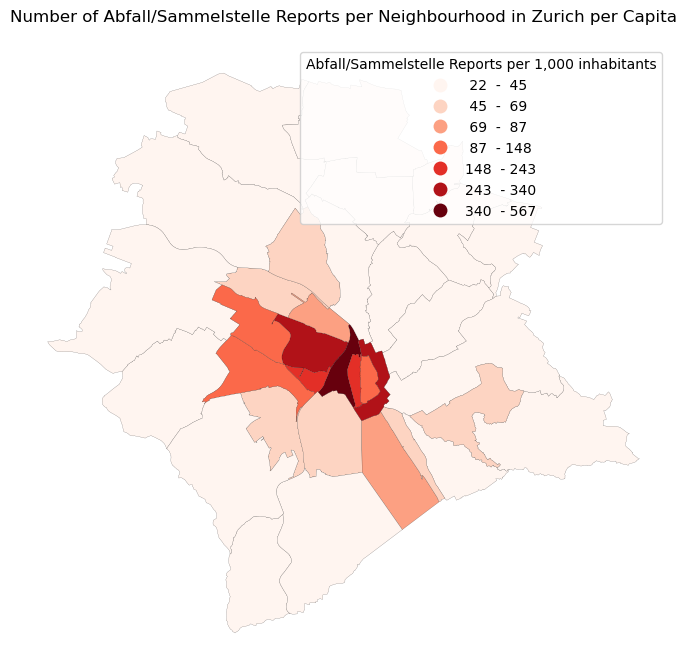

C:\Users\arina\miniconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


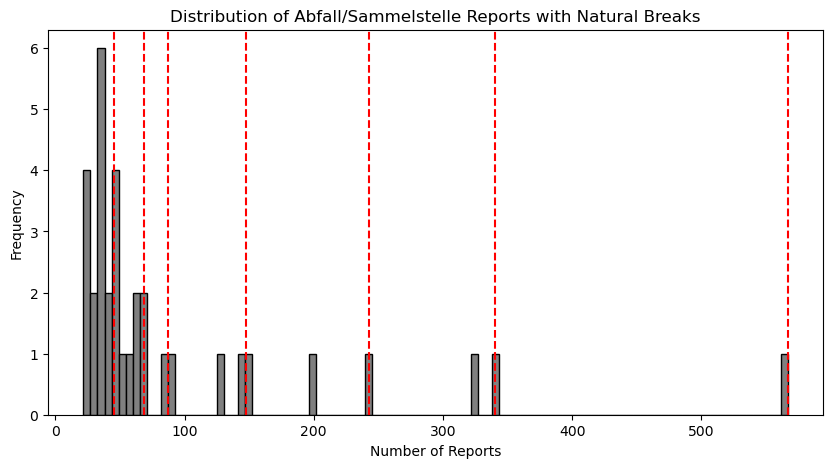

In [69]:
# ------------------------------------------------------------
# Prepare population and category data
# ------------------------------------------------------------
quartier_popsize=processed_quartiere.merge(pop_size, on="Quartier",how="left")

# Filter for selected issue category (changeable)
filtered_category = count[count["category"]=="Abfall/Sammelstelle"]

category_quartier_popsize=quartier_popsize.merge(filtered_category, on = "Quartier", how="left")

#---------------------------------------------------------------------------------------------------
#Data Analysis: Calculate number of reports per 1,000 inhabitants per neighbourhood
#---------------------------------------------------------------------------------------------------
category_quartier_popsize["Abfallreports_per_capita"] = (category_quartier_popsize["count"]/category_quartier_popsize["PopSize"]*1000)


#---------------------------------------------------------------------------------------------------------
# Create Chloropleth Map
#---------------------------------------------------------------------------------------------------------

fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


category_quartier_popsize.plot(
    column="Abfallreports_per_capita",
   scheme = "naturalbreaks",
   k = 7,
   edgecolor = "black",
    legend=True,
    linewidth = 0.1,
    cmap="Reds",
    ax=ax, #draw the axes on the axes we creaed
    legend_kwds={"title": "Abfall/Sammelstelle Reports per 1,000 inhabitants","fmt": "{:.0f}"}
)
legend = ax.get_legend()
for text in legend.get_texts():
    text.set_text(text.get_text().replace(",", "  -"))
ax.set_title("Number of Abfall/Sammelstelle Reports per Neighbourhood in Zurich per Capita")

ax.axis("off")
plt.show()

#--------------------------------------------------------------------------------------------------------
# Create histogram
#--------------------------------------------------------------------------------------------------------

# create natural break classifier and extract class breaks
classifier = mapclassify.NaturalBreaks(category_quartier_popsize["Abfallreports_per_capita"],k=7)
breaks = classifier.bins


plt.figure(figsize=(10,5))
plt.hist(category_quartier_popsize["Abfallreports_per_capita"], bins=100, color= "grey",edgecolor="black")

# Draw red lines at the Natural Break position
for i in breaks:
    plt.axvline(i, color="red", linestyle="--")

plt.title("Distribution of Abfall/Sammelstelle Reports with Natural Breaks")
plt.xlabel("Number of Reports")
plt.ylabel("Frequency")

plt.show()








In [58]:
# ------------------------------------------------------------
# Prepare population and category data
# ------------------------------------------------------------
quartier_popsize=processed_quartiere.merge(pop_size, on="Quartier",how="left")

# Filter for selected issue category (changeable)
filtered_category = count[count["category"]=="Abfall/Sammelstelle"]

category_quartier_popsize=quartier_popsize.merge(filtered_category, on = "Quartier", how="left")

#---------------------------------------------------------------------------------------------------
#Data Analysis: Calculate number of reports per 1,000 inhabitants per neighbourhood
#---------------------------------------------------------------------------------------------------
category_quartier_popsize["Abfallreports_per_capita"] = (category_quartier_popsize["count"]/category_quartier_popsize["PopSize"]*1000)


#---------------------------------------------------------------------------------------------------------
# Create Chloropleth Map
#---------------------------------------------------------------------------------------------------------

#fig, ax = plt.subplots(figsize=(16,8)) # creates empty figure 


#category_quartier_popsize.plot(
  #  column="Abfallreports_per_capita",
  # scheme = "naturalbreaks",
  # k = 5,
 #  edgecolor = "black",
    #legend=True,
   # linewidth = 0.1,
  #  cmap="Reds",
 #   ax=ax, #draw the axes on the axes we creaed
  #  legend_kwds={"title": "Reports per 1,000 inhabitants","fmt": "{:.0f}"}
#)
#legend = ax.get_legend()
#for text in legend.get_texts():
  #  text.set_text(text.get_text().replace(",", "  -"))
#ax.set_title("Number of Reports per Neighbourhood in Zurich per Capita")

#ax.axis("off")
#plt.show()

category_quartier_popsize


,Quartier,Geometry,PopSize,StichtagDatJahr,category,count,Abfallreports_per_capita
0,Alt-Wiedikon,"POLYGON ((2680606.8 1247034.6, 2680626.2 12470...",18904,2025,Abfall/Sammelstelle,1273,67.340245
1,Witikon,"POLYGON ((2685858.8 1246502.6, 2685860.8 12465...",11984,2025,Abfall/Sammelstelle,260,21.695594
2,Langstrasse,"POLYGON ((2681313.2 1248613.9, 2681459.5 12488...",11978,2025,Abfall/Sammelstelle,3853,321.673067
3,Escher Wyss,"POLYGON ((2680009.2 1249565, 2680055.8 1249565...",6426,2025,Abfall/Sammelstelle,358,55.711173
4,Enge,"POLYGON ((2681898.2 1246379.6, 2681899 1246410...",10015,2025,Abfall/Sammelstelle,689,68.796805
5,Weinegg,"POLYGON ((2684268.5 1246568.8, 2684269 1246569...",5701,2025,Abfall/Sammelstelle,253,44.378179
6,Seefeld,"POLYGON ((2683358.5 1246403.5, 2683604.5 12465...",5798,2025,Abfall/Sammelstelle,507,87.443946
7,Leimbach,"POLYGON ((2680272.5 1242790.9, 2680279.8 12428...",6316,2025,Abfall/Sammelstelle,261,41.323623
8,Wollishofen,"POLYGON ((2681417 1244793.5, 2681418 1244817.4...",22029,2025,Abfall/Sammelstelle,862,39.130237
9,Mühlebach,"POLYGON ((2683784.2 1246610.5, 2683801.5 12466...",6437,2025,Abfall/Sammelstelle,388,60.276526
